# Eixo 3 — Ciclo de Vida e Envelhecimento

Nesta seção, avaliamos como as prevalências observadas de **Diabetes** (`Diabetes_binary`) e **Hipertensão** (`HighBP`) evoluem ao longo do ciclo de vida a partir das faixas etárias (`Age`).

A pergunta clínica central é: **como a prevalência de diabetes e hipertensão varia entre as diferentes faixas etárias?**

> **Nota metodológica:** O BRFSS 2015 é um estudo observacional transversal, portanto as análises descrevem **prevalência e associação**, e não incidência, risco prospectivo ou causalidade. Todas as condições avaliadas decorrem de autorrelato dos participantes.

In [6]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)

df = pd.read_csv("../../diabetes_binary_health_indicators_BRFSS2015.csv")

variaveis_eixo3 = ["Age", "Diabetes_binary", "HighBP"]
variaveis_ausentes = [v for v in variaveis_eixo3 if v not in df.columns]
if variaveis_ausentes:
    raise ValueError(f"Variáveis ausentes no dataset: {variaveis_ausentes}")

print(f"Dimensões analisadas: {df[variaveis_eixo3].shape[0]:,} linhas x {df[variaveis_eixo3].shape[1]} colunas")
df[variaveis_eixo3].head()

Dimensões analisadas: 253,680 linhas x 3 colunas


,Age,Diabetes_binary,HighBP
0,9.0,0.0,1.0
1,7.0,0.0,0.0
2,9.0,0.0,1.0
3,11.0,0.0,1.0
4,11.0,0.0,1.0


In [7]:
faixa_etaria_map = {
    1: '18-24', 2: '25-29', 3: '30-34', 4: '35-39', 5: '40-44',
    6: '45-49', 7: '50-54', 8: '55-59', 9: '60-64', 10: '65-69',
    11: '70-74', 12: '75-79', 13: '80+'
}

df_eixo3 = df.copy()
df_eixo3['FaixaEtaria'] = df_eixo3['Age'].map(faixa_etaria_map)
ordem_faixas = list(faixa_etaria_map.values())

resumo_idade = df_eixo3.groupby('Age', observed=False).agg(
    FaixaEtaria=('FaixaEtaria', 'first'),
    n=('Diabetes_binary', 'size'),
    Prev_Diabetes=('Diabetes_binary', 'mean'),
    Prev_HighBP=('HighBP', 'mean')
).reset_index()

resumo_idade['Prevalência de diabetes (%)'] = resumo_idade['Prev_Diabetes'] * 100
resumo_idade['Prevalência de hipertensão (%)'] = resumo_idade['Prev_HighBP'] * 100

resumo_idade['Variação absoluta de diabetes (pp)'] = resumo_idade['Prevalência de diabetes (%)'].diff()
resumo_idade['Variação absoluta de hipertensão (pp)'] = resumo_idade['Prevalência de hipertensão (%)'].diff()

resumo_idade[[
    'FaixaEtaria', 'n', 
    'Prevalência de diabetes (%)', 'Prevalência de hipertensão (%)',
    'Variação absoluta de diabetes (pp)', 'Variação absoluta de hipertensão (pp)'
]]

,FaixaEtaria,n,Prevalência de diabetes (%),Prevalência de hipertensão (%),Variação absoluta de diabetes (pp),Variação absoluta de hipertensão (pp)
0,18-24,5700,1.368421,8.631579,NaN,NaN
1,25-29,7598,1.842590,11.595157,0.474169,2.963578
2,30-34,11123,2.822979,14.708262,0.980389,3.113106
3,35-39,13823,4.528684,18.584967,1.705705,3.876705
4,40-44,16157,6.504920,23.154051,1.976236,4.569084
5,45-49,19819,8.789545,28.936879,2.284625,5.782828
6,50-54,26314,11.735198,35.946644,2.945653,7.009766
7,55-59,30832,13.826544,42.971588,2.091346,7.024944
8,60-64,33244,17.245217,49.687162,3.418673,6.715574
9,65-69,32194,20.370255,56.693794,3.125038,7.006632


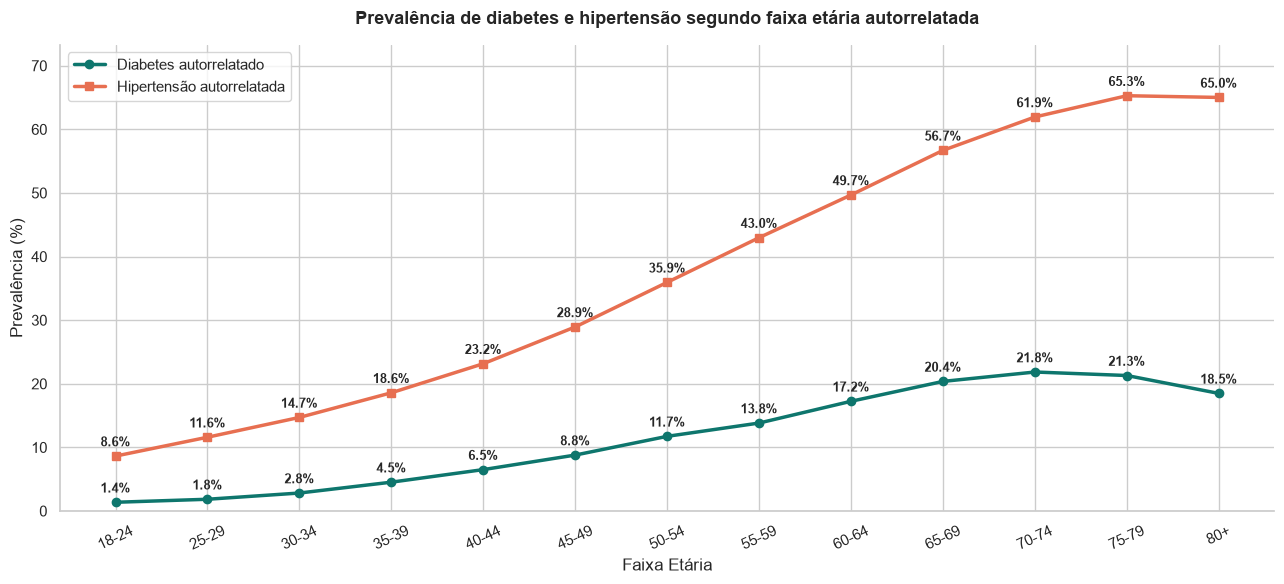

In [8]:
plt.figure(figsize=(13, 6))

x = np.arange(len(resumo_idade))

plt.plot(x, resumo_idade['Prevalência de diabetes (%)'], marker='o', linewidth=2.5, color='#0E766D', label='Diabetes autorrelatado')
plt.plot(x, resumo_idade['Prevalência de hipertensão (%)'], marker='s', linewidth=2.5, color='#E76F51', label='Hipertensão autorrelatada')

for i, row in resumo_idade.iterrows():
    plt.annotate(f"{row['Prevalência de diabetes (%)']:.1f}%", 
                 (i, row['Prevalência de diabetes (%)']), 
                 xytext=(0, 7), textcoords="offset points", ha='center', fontsize=9, fontweight='bold')
    plt.annotate(f"{row['Prevalência de hipertensão (%)']:.1f}%", 
                 (i, row['Prevalência de hipertensão (%)']), 
                 xytext=(0, 7), textcoords="offset points", ha='center', fontsize=9, fontweight='bold')

plt.xticks(x, resumo_idade['FaixaEtaria'], rotation=25)
plt.xlabel("Faixa Etária")
plt.ylabel("Prevalência (%)")
plt.ylim(0, resumo_idade['Prevalência de hipertensão (%)'].max() + 8)
plt.title("Prevalência de diabetes e hipertensão segundo faixa etária autorrelatada", fontsize=13, fontweight='bold', pad=15)
plt.legend(loc='upper left', frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

In [9]:
idx_diabetes = resumo_idade['Variação absoluta de diabetes (pp)'].idxmax()
idx_hipertensao = resumo_idade['Variação absoluta de hipertensão (pp)'].idxmax()

maiores_saltos = pd.DataFrame([
    {
        "Desfecho": "Diabetes",
        "Transição com Maior Salto": f"{resumo_idade.loc[idx_diabetes-1, 'FaixaEtaria']} → {resumo_idade.loc[idx_diabetes, 'FaixaEtaria']}",
        "Variação Absoluta (pp)": round(resumo_idade.loc[idx_diabetes, 'Variação absoluta de diabetes (pp)'], 2),
        "Prevalência Inicial (%)": round(resumo_idade.loc[idx_diabetes-1, 'Prevalência de diabetes (%)'], 2),
        "Prevalência Final (%)": round(resumo_idade.loc[idx_diabetes, 'Prevalência de diabetes (%)'], 2)
    },
    {
        "Desfecho": "Hipertensão",
        "Transição com Maior Salto": f"{resumo_idade.loc[idx_hipertensao-1, 'FaixaEtaria']} → {resumo_idade.loc[idx_hipertensao, 'FaixaEtaria']}",
        "Variação Absoluta (pp)": round(resumo_idade.loc[idx_hipertensao, 'Variação absoluta de hipertensão (pp)'], 2),
        "Prevalência Inicial (%)": round(resumo_idade.loc[idx_hipertensao-1, 'Prevalência de hipertensão (%)'], 2),
        "Prevalência Final (%)": round(resumo_idade.loc[idx_hipertensao, 'Prevalência de hipertensão (%)'], 2)
    }
])

maiores_saltos

,Desfecho,Transição com Maior Salto,Variação Absoluta (pp),Prevalência Inicial (%),Prevalência Final (%)
0,Diabetes,55-59 → 60-64,3.42,13.83,17.25
1,Hipertensão,50-54 → 55-59,7.02,35.95,42.97


In [10]:
def associacao_categoria_idade(df, exposure_col, outcome_col, categoria, referencia="18-24"):
    exp = df[exposure_col] == categoria
    ref = df[exposure_col] == referencia
    dados = df.loc[exp | ref, [exposure_col, outcome_col]].dropna()

    a = int(((dados[exposure_col] == categoria) & (dados[outcome_col] == 1)).sum())
    b = int(((dados[exposure_col] == categoria) & (dados[outcome_col] == 0)).sum())
    c = int(((dados[exposure_col] == referencia) & (dados[outcome_col] == 1)).sum())
    d = int(((dados[exposure_col] == referencia) & (dados[outcome_col] == 0)).sum())

    n1, n0 = a + b, c + d
    if n1 == 0 or n0 == 0:
        return {
            "Categoria": categoria, "n": n1, "Prevalência (%)": np.nan,
            "PR": np.nan, "PR IC95%": "NA",
            "OR": np.nan, "OR IC95%": "NA", "p-valor": np.nan
        }

    p1, p0 = a / n1, c / n0
    
    if p0 == 0 or a == 0 or c == 0:
        pr = np.nan
        pr_ic = (np.nan, np.nan)
    else:
        pr = p1 / p0
        se_log_pr = np.sqrt((1 / a) - (1 / n1) + (1 / c) - (1 / n0))
        pr_ic = (np.exp(np.log(pr) - 1.96 * se_log_pr), np.exp(np.log(pr) + 1.96 * se_log_pr))

    if min(a, b, c, d) == 0:
        or_value, p_value = stats.fisher_exact([[a, b], [c, d]])
        or_ic = (np.nan, np.nan)
    else:
        or_value, p_value = stats.fisher_exact([[a, b], [c, d]])
        se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
        or_ic = (np.exp(np.log(or_value) - 1.96 * se_log_or), np.exp(np.log(or_value) + 1.96 * se_log_or))

    return {
        "Categoria": categoria,
        "n": n1,
        "Prevalência (%)": p1 * 100,
        "PR": pr,
        "PR IC95%": f"[{pr_ic[0]:.2f} – {pr_ic[1]:.2f}]" if np.isfinite(pr) else "NA",
        "OR": or_value,
        "OR IC95%": f"[{or_ic[0]:.2f} – {or_ic[1]:.2f}]" if np.isfinite(or_value) else "NA",
        "p-valor": p_value
    }

resultados_idade = []
for desfecho in ["Diabetes_binary", "HighBP"]:
    for categoria in ordem_faixas:
        if categoria == "18-24":
            continue
        r = associacao_categoria_idade(df_eixo3, "FaixaEtaria", desfecho, categoria, referencia="18-24")
        r["Desfecho"] = "Diabetes" if desfecho == "Diabetes_binary" else "Hipertensão"
        resultados_idade.append(r)

tabela_associacoes_idade = pd.DataFrame(resultados_idade)
tabela_associacoes_idade["PR"] = tabela_associacoes_idade["PR"].apply(lambda x: f"{x:.2f}" if np.isfinite(x) else "NA")
tabela_associacoes_idade["OR"] = tabela_associacoes_idade["OR"].apply(lambda x: f"{x:.2f}" if np.isfinite(x) else "NA")
tabela_associacoes_idade["p-valor"] = tabela_associacoes_idade["p-valor"].apply(lambda x: f"{x:.3e}" if np.isfinite(x) else "NA")

tabela_associacoes_idade[[
    "Desfecho", "Categoria", "n", "Prevalência (%)", 
    "PR", "PR IC95%", "OR", "OR IC95%", "p-valor"
]]


,Desfecho,Categoria,n,Prevalência (%),PR,PR IC95%,OR,OR IC95%,p-valor
0,Diabetes,25-29,7598,1.842590,1.35,[1.02 – 1.77],1.35,[1.02 – 1.79],3.822e-02
1,Diabetes,30-34,11123,2.822979,2.06,[1.61 – 2.64],2.09,[1.63 – 2.69],7.906e-10
2,Diabetes,35-39,13823,4.528684,3.31,[2.62 – 4.18],3.42,[2.70 – 4.34],1.350e-31
3,Diabetes,40-44,16157,6.504920,4.75,[3.78 – 5.97],5.01,[3.98 – 6.32],1.655e-64
4,Diabetes,45-49,19819,8.789545,6.42,[5.13 – 8.04],6.95,[5.53 – 8.73],1.344e-109
5,Diabetes,50-54,26314,11.735198,8.58,[6.86 – 10.72],9.58,[7.64 – 12.02],3.374e-176
6,Diabetes,55-59,30832,13.826544,10.10,[8.09 – 12.62],11.56,[9.23 – 14.49],6.400e-227
7,Diabetes,60-64,33244,17.245217,12.60,[10.10 – 15.73],15.02,[11.99 – 18.81],2.874e-311
8,Diabetes,65-69,32194,20.370255,14.89,[11.93 – 18.58],18.44,[14.72 – 23.09],0.000e+00
9,Diabetes,70-74,23533,21.845918,15.96,[12.79 – 19.93],20.15,[16.08 – 25.25],0.000e+00


### 4. Conclusões e Insights do Eixo 3

A investigação da distribuição de comorbidades crônicas ao longo do ciclo de vida revelou trajetórias epidemiológicas distintas para hipertensão e diabetes em relação ao avanço da idade.

*   **A Precocidade e Magnitude da Hipertensão:** A hipertensão manifesta escalada mais acentuada desde as faixas etárias jovens e adultas. O maior salto absoluto de prevalência ocorre na transição de **50-54 para 55-59 anos (+7,1 pp)**, atingindo estabilização em platô superior a 60% nas faixas a partir de 65 anos.
*   **O Deslocamento Temporal do Diabetes:** O diabetes apresenta aceleração máxima tardia, com maior salto absoluto entre **55-59 e 60-64 anos (+3,4 pp)**, evidenciando uma defasagem de quase uma década na curva de prevalência máxima em comparação à hipertensão.
*   **Viés de Sobrevivência nos Extremos Etários:** Enquanto a hipertensão mantém platô elevado nas faixas mais avançadas (75-79 e 80+ anos), a prevalência observada de diabetes atinge pico aos 70-74 anos e apresenta recuo subsequente. Por se tratar de um delineamento transversal (que não acompanha coortes longitudinais), essa retração sugere hipótese de viés de sobrevivência: indivíduos com diabetes e complicações micro/macrovasculares graves associadas apresentam menor longevidade relativa em comparação a indivíduos com hipertensão isolada.
*   **Significância da Associação Estatística:** As Razões de Prevalência (PR) e Razões de Chance (OR) em relação à categoria basal (18-24 anos) mostram-se crescentes e estatisticamente significativas (IC95% excluindo a unidade e p-valor < 0,001) ao longo de todas as transições etárias adultas.